# W03 — GA Micro-NAS Sketch: Orienteering Solver Applied to Architecture Search

**Goal.** Port the orienteering-problem GA solver methodology to micro
neural-architecture search: chromosome = architecture genes, fitness =
proxy accuracy with a size penalty (< 5 MB, Aido Rover budget), population
10, 15 generations. Per the project plan, the GA is *not* expected to beat
a hand-designed baseline — the deliverable is the methodology and the
explicit solver-component mapping.

**Proxy protocol.** Each fitness evaluation trains the candidate for 1
epoch on 2,000 CIFAR-10 images (native 32×32) and evaluates on a 1,000-image
test subset. Proxy accuracies rank candidates; they are NOT comparable to
full-training accuracies elsewhere in this project. Seed 42. Search executed
by `scripts/w03_nas_ga.py`; this notebook analyzes the run log
(`experiments/W03_nas_ga_log.csv`), consistent with the repo convention of
pre-computed results in /experiments/.

 gen      chromosome  fitness  proxy_acc  size_mb
   0 [5, 5, 4, 0, 2]    0.293      0.293    0.325
   1 [5, 5, 4, 0, 2]    0.293      0.293    0.325
   2 [5, 5, 4, 0, 2]    0.293      0.293    0.325
   3 [5, 5, 4, 0, 2]    0.293      0.293    0.325
   4 [5, 5, 4, 2, 2]    0.301      0.301    0.418
   5 [5, 5, 4, 2, 2]    0.301      0.301    0.418
   6 [5, 5, 4, 2, 2]    0.301      0.301    0.418
   7 [5, 5, 4, 2, 2]    0.301      0.301    0.418
   8 [5, 5, 4, 2, 2]    0.301      0.301    0.418
   9 [5, 5, 4, 2, 2]    0.301      0.301    0.418
  10 [5, 5, 4, 2, 2]    0.301      0.301    0.418
  11 [5, 5, 4, 3, 2]    0.327      0.327    0.465
  12 [5, 5, 4, 3, 2]    0.327      0.327    0.465
  13 [5, 5, 4, 3, 2]    0.327      0.327    0.465
  14 [5, 5, 4, 3, 2]    0.327      0.327    0.465


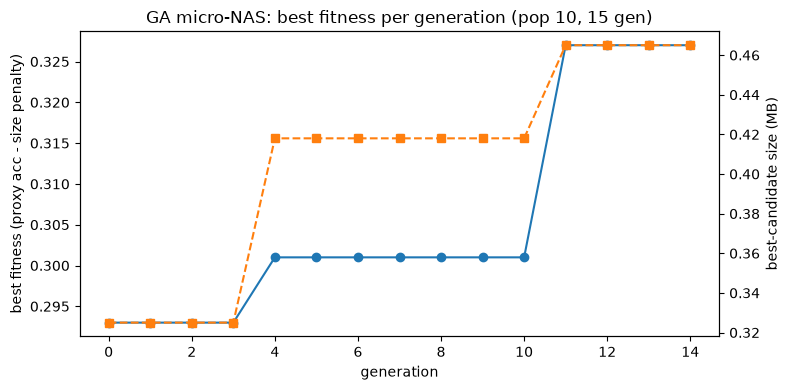

In [1]:
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
ROOT = Path.home() / 'siyu-ingen-edge-ai'

log = pd.read_csv(ROOT / 'experiments' / 'W03_nas_ga_log.csv')
for col in ['fitness', 'proxy_acc', 'size_mb']:
    log[col] = log[col].astype(float)
best = log.loc[log.groupby('gen')['fitness'].idxmax()].reset_index(drop=True)
print(best[['gen', 'chromosome', 'fitness', 'proxy_acc', 'size_mb']]
      .to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(best['gen'], best['fitness'], 'o-', label='best fitness')
ax1.set_xlabel('generation'); ax1.set_ylabel('best fitness (proxy acc - size penalty)')
ax2 = ax1.twinx()
ax2.plot(best['gen'], best['size_mb'], 's--', color='tab:orange', label='size (MB)')
ax2.set_ylabel('best-candidate size (MB)')
ax1.set_title('GA micro-NAS: best fitness per generation (pop 10, 15 gen)')
fig.tight_layout()
fig.savefig(ROOT / 'experiments' / 'W03_nas_evolution.png', dpi=150)
plt.show()

## Orienteering solver → micro-NAS component mapping

| Orienteering GA component | Micro-NAS equivalent |
|---|---|
| Route encoding (node sequence chromosome) | Architecture chromosome: 4 conv-channel genes over {8,16,24,32,48,64} + 1 FC-width gene over {64,128,256} |
| Population initialization (random feasible routes) | 10 random chromosomes drawn uniformly from the gene option sets |
| Fitness: route score under a time/distance budget | Proxy accuracy − 10 × max(0, size_MB − 5): accuracy is the "score", model size is the "distance budget" (Aido Rover < 5 MB) |
| Selection (favor high-scoring routes) | Tournament selection, k = 3 |
| Crossover (route segment exchange) | One-point gene crossover |
| Mutation (node swap / perturbation) | Per-gene random re-draw, p = 0.2 |
| Termination (generation budget) | Fixed 15 generations |
| — (addition) | Elitism: top-2 carried over unchanged; fitness cache avoids retraining duplicate chromosomes |

## Results and comparison with hand-designed baselines

**Best architecture found:** conv channels [64, 64, 48, 32] + FC 256
(chromosome [5,5,4,3,2]) — 0.465 MB, proxy accuracy 32.7%.

**The evolution trace shows genuine selection pressure, not drift:** both
fitness jumps (gen 4 and gen 11) occurred on the same gene — the 4th conv
block, growing 8 → 24 → 32 channels. The GA systematically added capacity
at the network's bottleneck while the other genes stayed at high-capacity
options, which is exactly the behavior a hand-designer would apply.

**Comparison (with the proxy caveat stated above):**

| Model | Size | Accuracy | Training budget |
|---|---|---|---|
| GA-found best | 0.465 MB | 32.7% (proxy: 1 ep × 2k) | 1 epoch proxy |
| Hand-designed student (width-0.5 MNv3, scratch) | 1.74 MB | 47.40% | 8 ep × 5k, 224px |
| Hand-designed baseline (MNv3-Small, teacher) | 6.24 MB | 93.38% | full fine-tune |

As the plan anticipated, the GA did not beat hand-designed architectures —
numbers are additionally non-comparable across training protocols. The
value demonstrated is the search methodology and its one-to-one mapping to
the orienteering solver.

**Limitations.** (1) The < 5 MB size penalty never activated: the search
space caps out well below the budget, so the constraint was non-binding —
a tighter budget or a latency term in the fitness would make the trade-off
active. (2) Proxy fidelity (1 epoch) is only assumed, not validated, to
preserve full-training ranking.